In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import csv
import math
import random
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt

import json, codecs
import seaborn as sns
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

In [2]:
# Set the path to the file you'd like to load
test_path = "fashion-mnist_test.csv"

# Load the latest version of the test data
test_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  test_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", test_data.head())

Using Colab cache for faster access to the 'fashionmnist' dataset.
First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0     

In [3]:
# Set the path to the file you'd like to load
train_path = "fashion-mnist_train.csv"

# Load the latest version of the train data
train_data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  train_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", train_data.head())


Using Colab cache for faster access to the 'fashionmnist' dataset.
First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0     

In [4]:
train_data['label'].describe()
test_data['label'].describe()

#labels range from 0-9

train_data.info() #60000 entries
test_data.info() #10000 entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [5]:
X_train = train_data.drop(["label"], axis=1).values
Y_train = train_data.label.values
X_test = test_data.drop(["label"], axis=1).values
Y_test = test_data.label.values

print("X_train shape:", np.shape(X_train))
print("Y_train shape:", np.shape(Y_train))
print("X_test shape:", np.shape(X_test))
print("Y_test shape:", np.shape(X_train))

X_train shape: (60000, 784)
Y_train shape: (60000,)
X_test shape: (10000, 784)
Y_test shape: (60000, 784)


In [6]:
#normalise the data

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

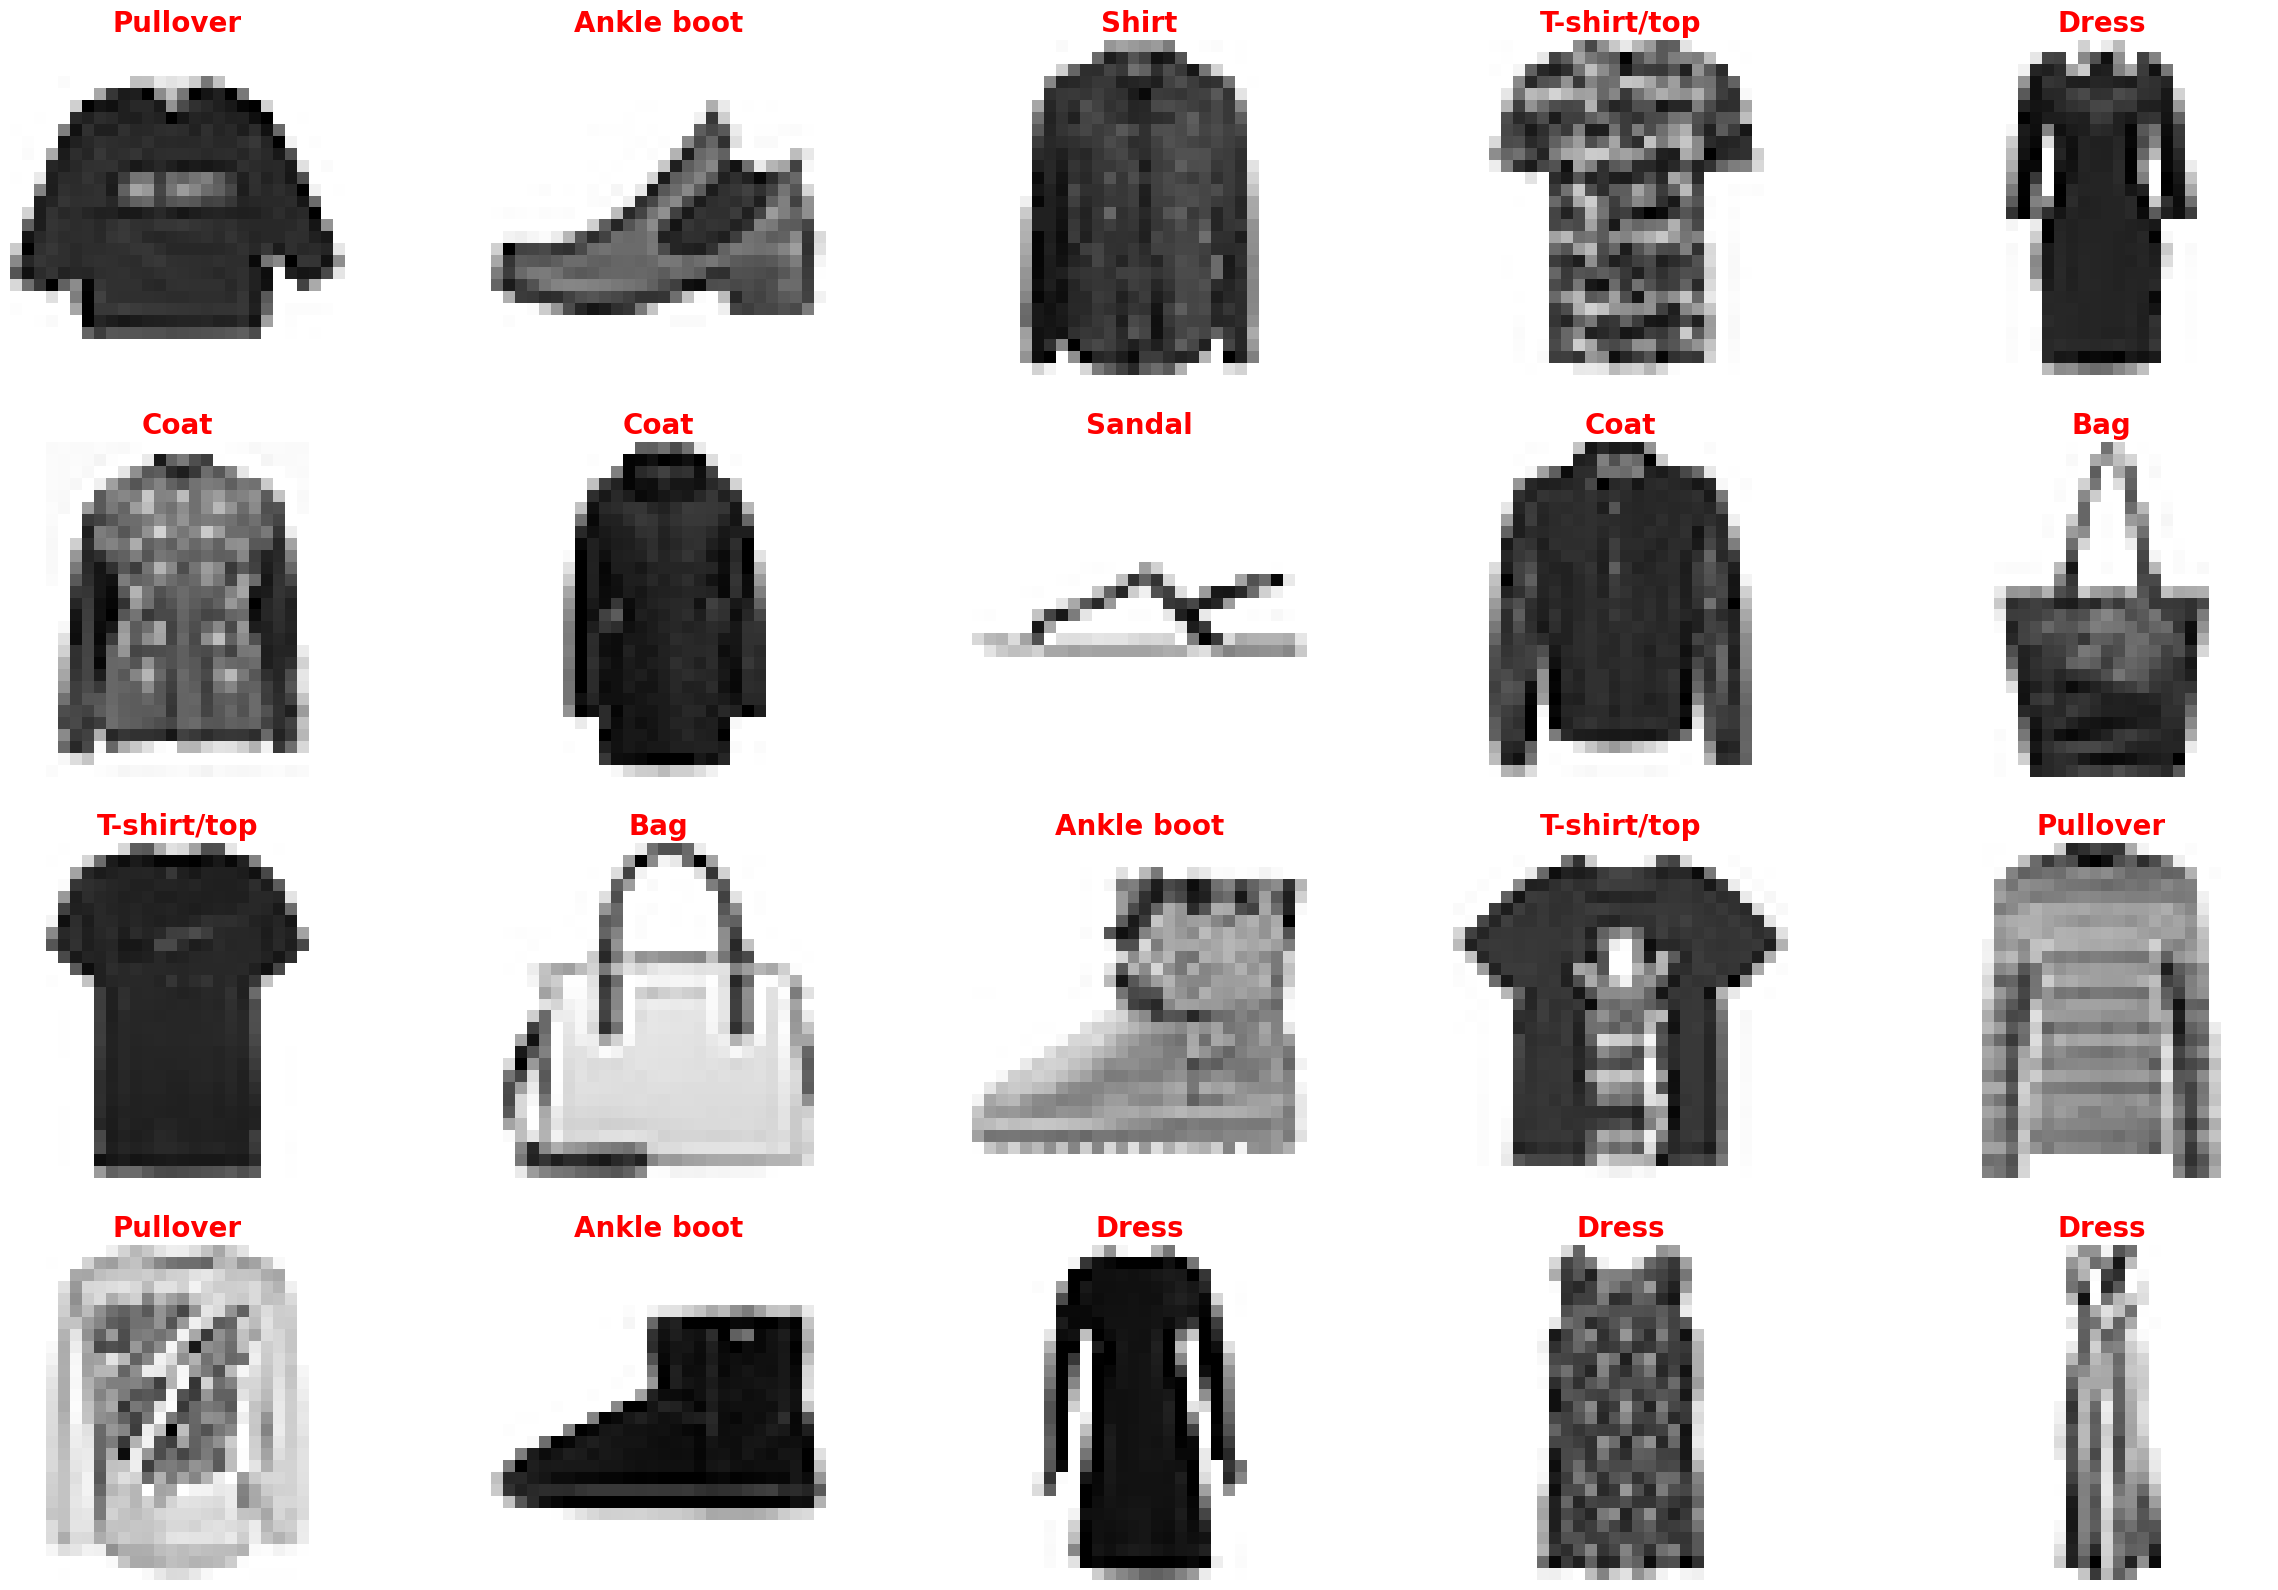

In [7]:
plt.figure(figsize=(30,20))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gist_yarg")
    plt.title("T-shirt/top" if Y_train[i] == 0
              else "Trouser" if Y_train[i] == 1
              else "Pullover" if Y_train[i] == 2
              else "Dress" if Y_train[i] == 3
              else "Coat" if Y_train[i] == 4
              else "Sandal" if Y_train[i] == 5
              else "Shirt" if Y_train[i] == 6
              else "Sneaker" if Y_train[i] == 7
              else "Bag" if Y_train[i] == 8
              else "Ankle boot",
              size = 20, color = "red", fontweight = "bold")
    plt.axis("off")

plt.show()

In [8]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_img = Input(shape = (784,))

In [9]:
encoded = Dense(32, activation="relu")(input_img)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

In [10]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer="rmsprop", loss="binary_crossentropy")

In [11]:
hist = autoencoder.fit(X_train,
                       X_train,
                       epochs=250,
                       batch_size=256,
                       shuffle=True,
                       validation_data=(X_train, X_train))

Epoch 1/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.4475 - val_loss: 0.3798
Epoch 2/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3654 - val_loss: 0.3523
Epoch 3/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3426 - val_loss: 0.3388
Epoch 4/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3314 - val_loss: 0.3288
Epoch 5/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.3248 - val_loss: 0.3215
Epoch 6/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3214 - val_loss: 0.3221
Epoch 7/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3189 - val_loss: 0.3189
Epoch 8/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3171 - val_loss: 0.3145
Epoch 9/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3155 - val_loss: 0.3140
Epoch 10/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3141 - val_loss: 0.3142
Epoch 11/250
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3128 - val_loss: 0.3112
Epoch 12/250
235/235 ━━━━━━━━━

In [12]:
encoder = Model(input_img, encoded)
encoded_img = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [13]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


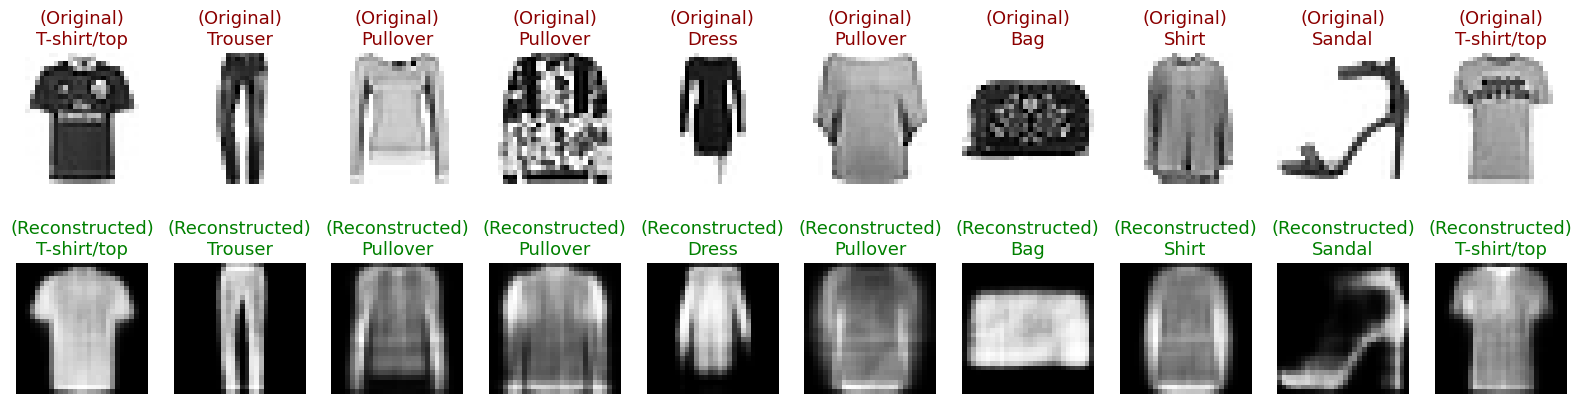

In [14]:
plt.figure(figsize=(20, 5))
for i in range(10):

    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gist_yarg")
    plt.title("(Original)\nT-shirt/top" if Y_test[i] == 0
              else "(Original)\nTrouser" if Y_test[i] == 1
              else "(Original)\nPullover" if Y_test[i] == 2
              else "(Original)\nDress" if Y_test[i] == 3
              else "(Original)\nCoat" if Y_test[i] == 4
              else "(Original)\nSandal" if Y_test[i] == 5
              else "(Original)\nShirt" if Y_test[i] == 6
              else "(Original)\nSneaker" if Y_test[i] == 7
              else "(Original)\nBag" if Y_test[i] == 8
              else "(Original)\nAnkle boot", size = 13, color = "darkred")
    plt.axis("off")

    plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.title("(Reconstructed)\nT-shirt/top" if Y_test[i] == 0
              else "(Reconstructed)\nTrouser" if Y_test[i] == 1
              else "(Reconstructed)\nPullover" if Y_test[i] == 2
              else "(Reconstructed)\nDress" if Y_test[i] == 3
              else "(Reconstructed)\nCoat" if Y_test[i] == 4
              else "(Reconstructed)\nSandal" if Y_test[i] == 5
              else "(Reconstructed)\nShirt" if Y_test[i] == 6
              else "(Reconstructed)\nSneaker" if Y_test[i] == 7
              else "(Reconstructed)\nBag" if Y_test[i] == 8
              else "(Reconstructed)\nAnkle boot", size = 13, color = "green")
    plt.axis("off")

plt.show()

In [15]:
## DENOISING AUTOENCODER (DAE) ##
  #Using a noise factor of 0.3,

X_train_dae = X_train + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_dae = X_test + 0.3 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

X_train_dae = np.clip(X_train_dae, 0., 1.)
X_test_dae = np.clip(X_test_dae, 0., 1.)

input_img_dae = Input(shape=(784,))

encoded_dae = Dense(32, activation='relu')(input_img_dae)
encoded_dae = Dense(16, activation='relu')(encoded_dae)

decoded_dae = Dense(32, activation='relu')(encoded_dae)
decoded_dae = Dense(784, activation='sigmoid')(decoded_dae)

dae = Model(input_img_dae, decoded_dae)

dae.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Denoising Autoencoder...")
dae.fit(X_train_dae, X_train,   # noisy → clean
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(X_test_dae, X_test))

Training Denoising Autoencoder...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.4307 - val_loss: 0.3565
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3390 - val_loss: 0.3284
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3245 - val_loss: 0.3203
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3186 - val_loss: 0.3158
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3147 - val_loss: 0.3123
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3121 - val_loss: 0.3102
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3102 - val_loss: 0.3086
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3087 - val_loss: 0.3072
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3076 - val_loss: 0.3062
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3067 - val_loss: 0.3055
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3059 - val_loss: 0.3049
Epoch 1

In [17]:
## SPARSE AUTOENCODER ##

from tensorflow.keras import regularizers

input_img_sparse = Input(shape=(784,))

encoded_sparse = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img_sparse)
encoded_sparse = Dense(16, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(encoded_sparse)

decoded_sparse = Dense(32, activation='relu')(encoded_sparse)
decoded_sparse = Dense(784, activation='sigmoid')(decoded_sparse)

sparse = Model(input_img_sparse, decoded_sparse)

sparse.compile(optimizer='adam', loss='binary_crossentropy')

print("Training Sparse Autoencoder...")
sparse.fit(X_train, X_train,
              epochs=20,
              batch_size=256,
              shuffle=True,
              validation_data=(X_test, X_test))

Training Sparse Autoencoder...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5524 - val_loss: 0.4321
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4113 - val_loss: 0.3907
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3828 - val_loss: 0.3745
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3671 - val_loss: 0.3592
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3549 - val_loss: 0.3504
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3489 - val_loss: 0.3455
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3450 - val_loss: 0.3425
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3422 - val_loss: 0.3398
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3401 - val_loss: 0.3381
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3381 - val_loss: 0.3366
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3363 - val_loss: 0.3349
Epoch 12/2

In [18]:
## VARIANT EVALUATION ##
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

autoencoder_train = autoencoder.predict(X_train)
autoencoder_test = autoencoder.predict(X_test)

knn_ae = KNeighborsClassifier(n_neighbors=5)
knn_ae.fit(autoencoder_train, Y_train)

pred_ae = knn_ae.predict(autoencoder_test)
acc_ae = accuracy_score(Y_test, pred_ae)

print("Baseline AE + KNN accuracy:", acc_ae)

dae_train = dae.predict(X_train)
dae_test = dae.predict(X_test)

knn_dae = KNeighborsClassifier(n_neighbors=5)
knn_dae.fit(dae_train, Y_train)

pred_dae = knn_dae.predict(dae_test)
acc_dae = accuracy_score(Y_test, pred_dae)

print("Denoising AE + KNN accuracy:", acc_dae)

sparse_train = sparse.predict(X_train)
sparse_test = sparse.predict(X_test)

knn_sparse = KNeighborsClassifier(n_neighbors=5)
knn_sparse.fit(sparse_train, Y_train)

pred_sparse = knn_sparse.predict(sparse_test)
acc_sparse = accuracy_score(Y_test, pred_sparse)

print("Sparse AE + KNN accuracy:", acc_sparse)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline AE + KNN accuracy: 0.8444
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Denoising AE + KNN accuracy: 0.8224
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Sparse AE + KNN accuracy: 0.7482


In [23]:
def plot_conf_matrix(y_true, y_pred, title, filename):
    mask = np.isin(y_true, focus_labels)
    y_true_f = y_true[mask]
    y_pred_f = y_pred[mask]

    cm = confusion_matrix(y_true_f, y_pred_f, labels=focus_labels)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_names,
                yticklabels=label_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.savefig(filename, bbox_inches='tight')
    plt.close()
plot_conf_matrix(Y_test, pred_ae, "Baseline AE", "baseline_cm.png")
plot_conf_matrix(Y_test, pred_dae, "Denoising AE", "denoising_cm.png")
plot_conf_matrix(Y_test, pred_sparse, "Sparse AE", "sparse_cm.png")

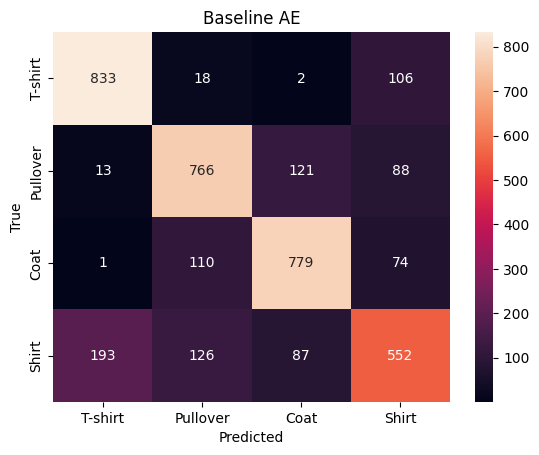

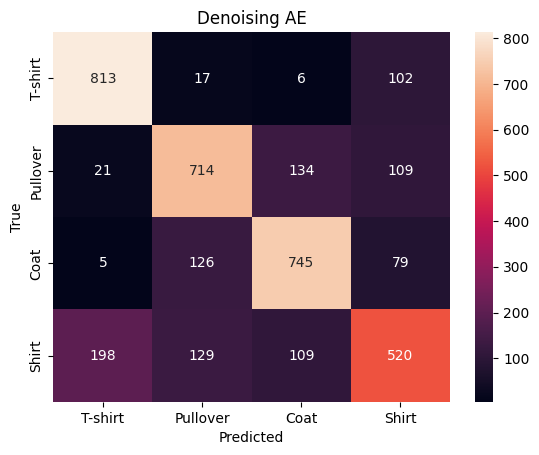

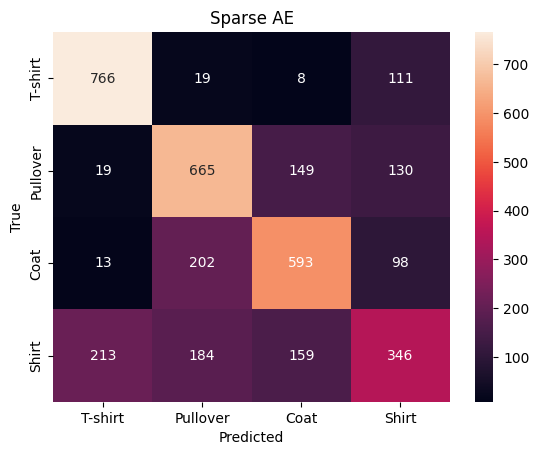

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from IPython.display import Image, display

display(Image("baseline_cm.png"))
display(Image("denoising_cm.png"))
display(Image("sparse_cm.png"))

from google.colab import files

files.download("baseline_cm.png")
files.download("denoising_cm.png")
files.download("sparse_cm.png")